# Proyecto 1: Predicción de la Popularidad Musical en Spotify mediante Random Forest Regressor

**Integrantes: Fernando Palma e Isidora Salgado.**

El presente proyecto toma como contexto el mercado global de la música digital, un entorno sumamente competitivo donde miles de canciones compiten constantemente por captar oyentes. El problema radica en descubrir qué rasgos sonoros son los que definen un éxito comercial. Para resolverlo, se busca entrenar un algoritmo que logre proyectar la popularidad de una pista basándose estrictamente en su perfil acústico, tales como su intensidad (`energy`), índice de bailabilidad (`danceability`), positividad musical (`valence`) y su velocidad (`tempo`).

## Análisis Exploratorio de los Datos
Para realizar el análisis exploratorio, tomaremos como referencia la metodología planteada en el documento *'A Practical Guide to Introduce Exploratory Data Analysis with Python'* [1]. El proceso consistirá en obtener una visión representativa del conjunto de datos mediante un análisis descriptivo y ajustar los tipos de variables para asegurar su consistencia. Posteriormente, gestionaremos los datos faltantes y outliers para evitar sesgos y distorsiones en los resultados estadísticos. Por último, examinaremos las relaciones numéricas y gráficas entre las variables.

In [6]:
# Se cargan las librerías necesarias
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import math

### Análisis Descriptivo

Para dar inicio al análisis, comenzamos con la importación del conjunto de datos. A continuación, desplegamos las primeras filas para realizar una inspección inicial y comprender la estructura general de la información.

In [7]:
# Se cargan los datos en un dataframe
data = pd.read_csv("spotify_songs.csv")

# Mostramos las primeras dos filas
data.head(2)

,track_id,track_name,track_artist,track_popularity,track_album_id,track_album_name,track_album_release_date,playlist_name,playlist_id,playlist_genre,...,key,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,duration_ms
0,6f807x0ima9a1j3VPbc7VN,I Don't Care (with Justin Bieber) - Loud Luxur...,Ed Sheeran,66,2oCs0DGTsRO98Gh5ZSl2Cx,I Don't Care (with Justin Bieber) [Loud Luxury...,2019-06-14,Pop Remix,37i9dQZF1DXcZDD7cfEKhW,pop,...,6,-2.634,1,0.0583,0.1020,0.00000,0.0653,0.518,122.036,194754
1,0r7CVbZTWZgbTCYdfa2P31,Memories - Dillon Francis Remix,Maroon 5,67,63rPSO264uRjW1X5E6cWv6,Memories (Dillon Francis Remix),2019-12-13,Pop Remix,37i9dQZF1DXcZDD7cfEKhW,pop,...,11,-4.969,1,0.0373,0.0724,0.00421,0.3570,0.693,99.972,162600


Al revisar la información estructural del DataFrame, confirmamos que estamos trabajando con más de 32,000 canciones y 23 columnas distintas. Lo más destacado es verificar que nuestros atributos sonoros (como energía o bailabilidad) ya son reconocidos como números, dejándolos casi listos para el algoritmo predictivo. Sin embargo, este comando también expone un pequeño problema de calidad de datos: nos faltan exactamente 5 registros en los nombres de las pistas y los artistas, un detalle que solucionaremos a continuación para evitar fallos en el modelo.

In [8]:
# Mostramos la estructura del data frame
data.info()

<class 'pandas.DataFrame'>
RangeIndex: 32833 entries, 0 to 32832
Data columns (total 23 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   track_id                  32833 non-null  str    
 1   track_name                32828 non-null  str    
 2   track_artist              32828 non-null  str    
 3   track_popularity          32833 non-null  int64  
 4   track_album_id            32833 non-null  str    
 5   track_album_name          32828 non-null  str    
 6   track_album_release_date  32833 non-null  str    
 7   playlist_name             32833 non-null  str    
 8   playlist_id               32833 non-null  str    
 9   playlist_genre            32833 non-null  str    
 10  playlist_subgenre         32833 non-null  str    
 11  danceability              32833 non-null  float64
 12  energy                    32833 non-null  float64
 13  key                       32833 non-null  int64  
 14  loudness         

También, se genera un resumen estadístico de las variables numéricas utilizando la función describe(). Con este paso, identificamos las medidas de tendencia central y sus rangos en cada variable. Estos resultados revelan la naturaleza y comportamiento general del conjunto de datos.

- En primera instancia, al profundizar en la variable principal, la popularidad de las pistas (`track_popularity`), observamos un promedio de 42.47 en una escala de 0 a 100. Sin embargo, lo más destacable es su alta desviación estándar de casi 25 puntos, lo que evidencia un mercado musical sumamente volátil. Existen canciones que son absolutos desconocidos (con un mínimo de 0) y otras que alcanzan el éxito mundial (máximo de 100). Además, dado que la mediana se sitúa en 45 puntos, levemente por encima del promedio, es posible inferir que existe un volumen considerable de canciones con un rendimiento muy bajo que arrastran la media general hacia abajo.

- Por otro lado, al evaluar el resto de las variables sonoras, podemos trazar un perfil acústico general del catálogo. Los datos nos indican que estamos frente a una colección dominada por la producción moderna y comercial, caracterizada por ser altamente enérgica (con una media de 0.69) y rítmica, destacando un índice de bailabilidad (`danceability`) promedio de 0.65 y un `tempo` estandarizado en torno a los 120.8 BPM. Asímismo, los niveles notablemente bajos en acústica (`acousticness`) de 0.17 e instrumentalidad (`instrumentalness`) de 0.08 reafirman que la mayoría de estas pistas corresponden a producciones con fuerte presencia vocal. Todas estas características en conjunto estructuran la identidad sonora actual, entregándole el contexto necesario para realizar sus proyecciones.

In [9]:
data.describe()

,track_popularity,danceability,energy,key,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,duration_ms
count,32833.000000,32833.000000,32833.000000,32833.000000,32833.000000,32833.000000,32833.000000,32833.000000,32833.000000,32833.000000,32833.000000,32833.000000,32833.000000
mean,42.477081,0.654850,0.698619,5.374471,-6.719499,0.565711,0.107068,0.175334,0.084747,0.190176,0.510561,120.881132,225799.811622
std,24.984074,0.145085,0.180910,3.611657,2.988436,0.495671,0.101314,0.219633,0.224230,0.154317,0.233146,26.903624,59834.006182
min,0.000000,0.000000,0.000175,0.000000,-46.448000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,4000.000000
25%,24.000000,0.563000,0.581000,2.000000,-8.171000,0.000000,0.041000,0.015100,0.000000,0.092700,0.331000,99.960000,187819.000000
50%,45.000000,0.672000,0.721000,6.000000,-6.166000,1.000000,0.062500,0.080400,0.000016,0.127000,0.512000,121.984000,216000.000000
75%,62.000000,0.761000,0.840000,9.000000,-4.645000,1.000000,0.132000,0.255000,0.004830,0.248000,0.693000,133.918000,253585.000000
max,100.000000,0.983000,1.000000,11.000000,1.275000,1.000000,0.918000,0.994000,0.994000,0.996000,0.991000,239.440000,517810.000000


Junto a esto y para profundizar en el análisis, se genera un panel de histogramas para visualizar la distribución de las variables numéricas, para así identificar concentraciones y sesgos de cada atributo sonoro.

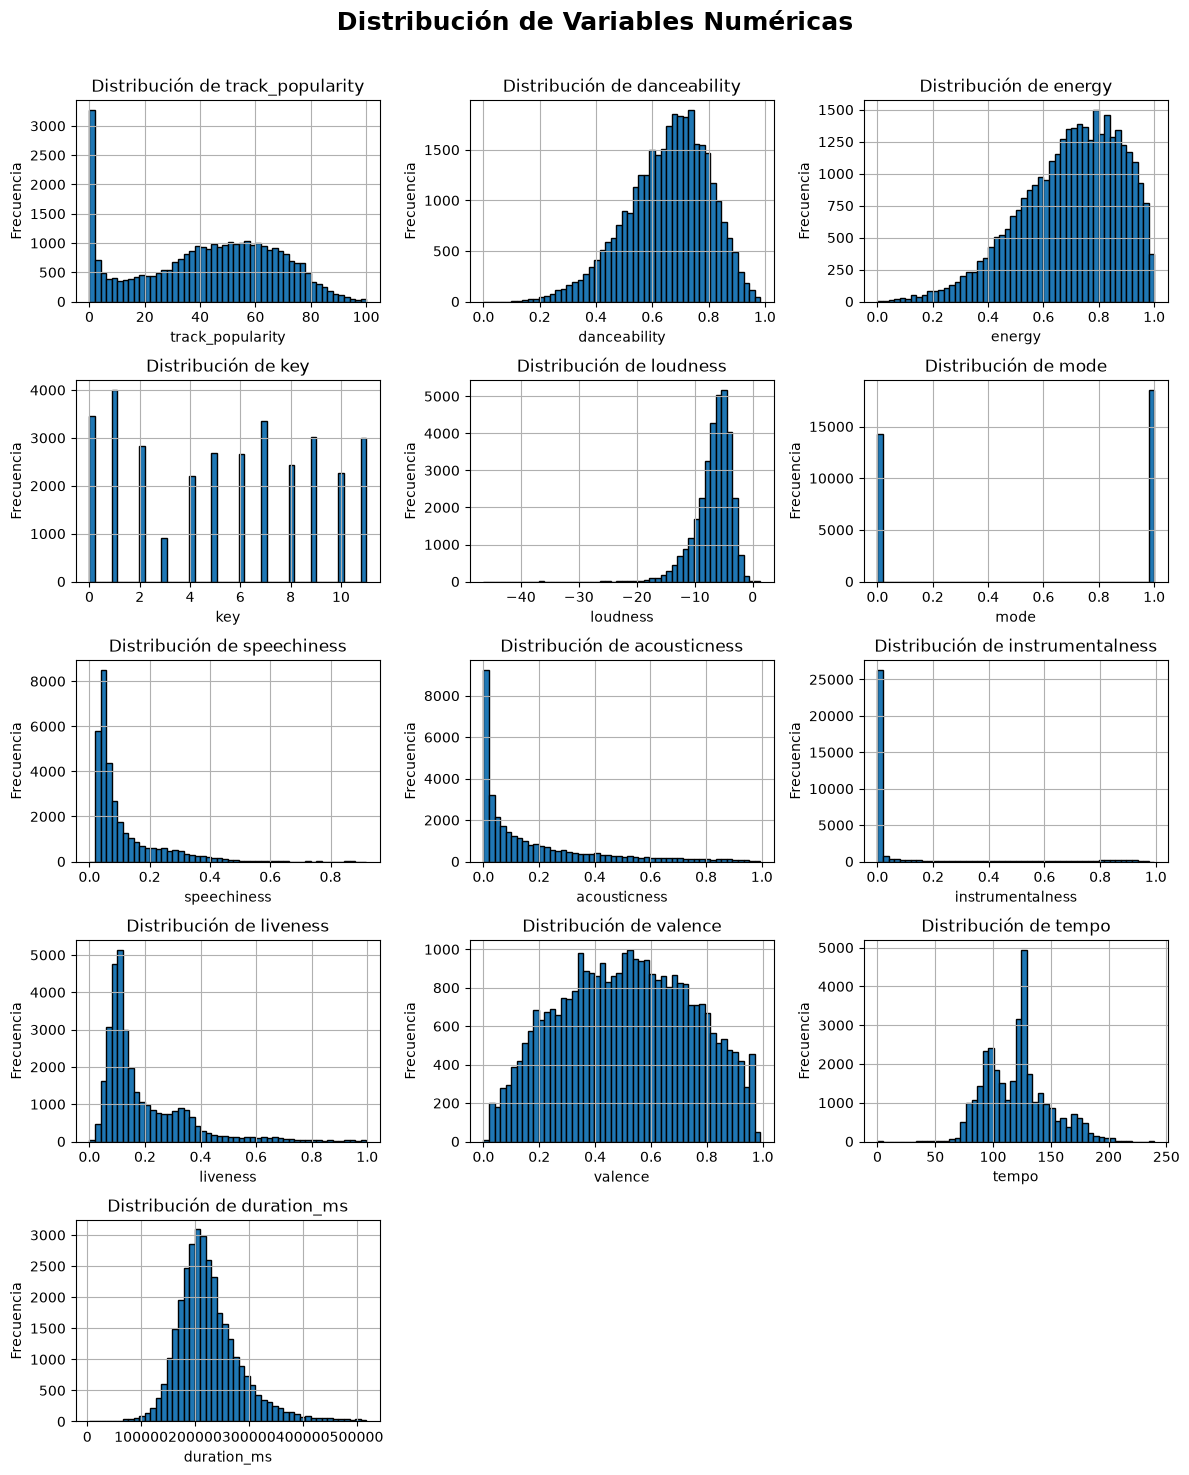

In [10]:
numColumns = data.select_dtypes(include=[np.number]).columns
n = len(numColumns)
ncols = 3
nrows = math.ceil(n / ncols)
fig, axes = plt.subplots(nrows=nrows, ncols=ncols, figsize=(12, 3*nrows)) 
fig.suptitle('Distribución de Variables Numéricas', fontsize=18, fontweight='bold') # Título principal bold
axes = np.array(axes).flatten()

for i, col in enumerate(numColumns):
    ax = axes[i]
    data[col].hist(ax=ax, bins=50, edgecolor='black')
    ax.set_title(f'Distribución de {col}', fontsize=12)
    ax.set_xlabel(col)
    ax.set_ylabel('Frecuencia')

for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.subplots_adjust(top=0.92)
plt.show()

En este caso, es interesante revisar la distribución de `track_popularity`, puesto que en ella estamos basando la investigación. Lo más interesante de este gráfico es el gran pico anómalo de canciones con popularidad cero y la enorme concentración en la zona media (40-60), lo que demuestra que los verdaderos éxitos comerciales son estadísticamente raros.

Por otro lado, al revisar el resto de las variables sonoras, se confirma el enfoque comercial y de estudio que tiene este catálogo. Atributos como la energía (`energy`) y la bailabilidad (`danceability`) se inclinan claramente hacia los valores más altos, mientras que características como la acústica (`acousticness`) o la presencia de palabras habladas (`speechiness`) se concentran masivamente en el cero. A su vez, métricas como el `tempo` y la positividad muestran una distribución mucho más equilibrada.

### Ajuste de Tipos de Variables
El siguiente paso consiste en ajustar los tipos de datos del conjunto para asegurar que el sistema interprete correctamente la naturaleza de cada columna. Específicamente, estandarizamos la fecha de lanzamiento del álbum (`track_album_release_date`) a un formato de tiempo (datetime). Además, se transforma el género (`playlist_genre`), subgénero (`playlist_subgenre`) y la nota musical (`key`) en variables categóricas. Finalmente, la modalidad de la pista (`mode`) se ajustó a un formato booleano, dado que es una variable estrictamente binaria que solo indica si la escala es mayor o menor.

In [11]:
data['track_album_release_date'] = pd.to_datetime(data['track_album_release_date'], errors='coerce')

columnas_categoricas = ['playlist_genre', 'playlist_subgenre']
for col in columnas_categoricas:
    data[col] = data[col].astype('category')

data['mode'] = data['mode'].astype(bool)
data['key'] = data['key'].astype('category')

### Detección y Tratamiento de Missing Data

Al evaluar la cantidad de datos faltantes en el conjunto, comprobamos que la proporción de valores nulos es prácticamente insignificante, representando apenas un 0.0025% del total. Siguiendo las prácticas de la referencia inicial, cuando los valores faltantes se encuentran en un número tan reducido de filas dentro de un dataset extenso, la estrategia más eficiente es la eliminación directa de dichas filas (*Row Deletion*). Optar por esta técnica nos permite limpiar la base de datos y evitar métodos de imputación innecesarios, asegurando al mismo tiempo que no se pierda información valiosa que pueda afectar el rendimiento de nuestro modelo predictivo.

In [12]:
data.isna().sum()
print(data.isna().mean().mean().round(5))

0.00252


In [13]:
dataNew = data.dropna()
dataNew.isna().sum()

track_id                    0
track_name                  0
track_artist                0
track_popularity            0
track_album_id              0
track_album_name            0
track_album_release_date    0
playlist_name               0
playlist_id                 0
playlist_genre              0
playlist_subgenre           0
danceability                0
energy                      0
key                         0
loudness                    0
mode                        0
speechiness                 0
acousticness                0
instrumentalness            0
liveness                    0
valence                     0
tempo                       0
duration_ms                 0
dtype: int64

Se decidió conservar los valores atípicos (outliers) en las variables acústicas, ya que en el dominio musical representan variaciones estilísticas válidas (ej. pistas de larga duración o géneros puramente instrumentales) y no errores de medición. Además, el modelo seleccionado (Random Forest) es robusto ante distribuciones asimétricas y valores extremos, por lo que estas anomalías no comprometen el entrenamiento, sino que enriquecen el espacio de características.

### Correlación de Variables

Para finalizar, se genera una matriz de correlación de Pearson mediante un mapa de calor, lo que es fundamental para evaluar las relaciones lineales entre nuestras variables y entender la estructura interna del conjunto de datos. Al observar la relación con la variable principal, el mapa revela que ninguna característica acústica individual presenta una correlación lineal fuerte con la popularidad (`track_popularity`). Lejos de ser un problema, este hallazgo justifica perfectamente la elección de un modelo Random Forest, ya que demuestra que el éxito musical depende de interacciones complejas y no lineales que este algoritmo basado en árboles sí es capaz de otorgar.

Por otro lado, existe una fuerte correlación positiva entre la energía (`energy`) y el volumen (`loudness`), así como una evidente correlación negativa entre la acústica (`acousticness`) y la energía.

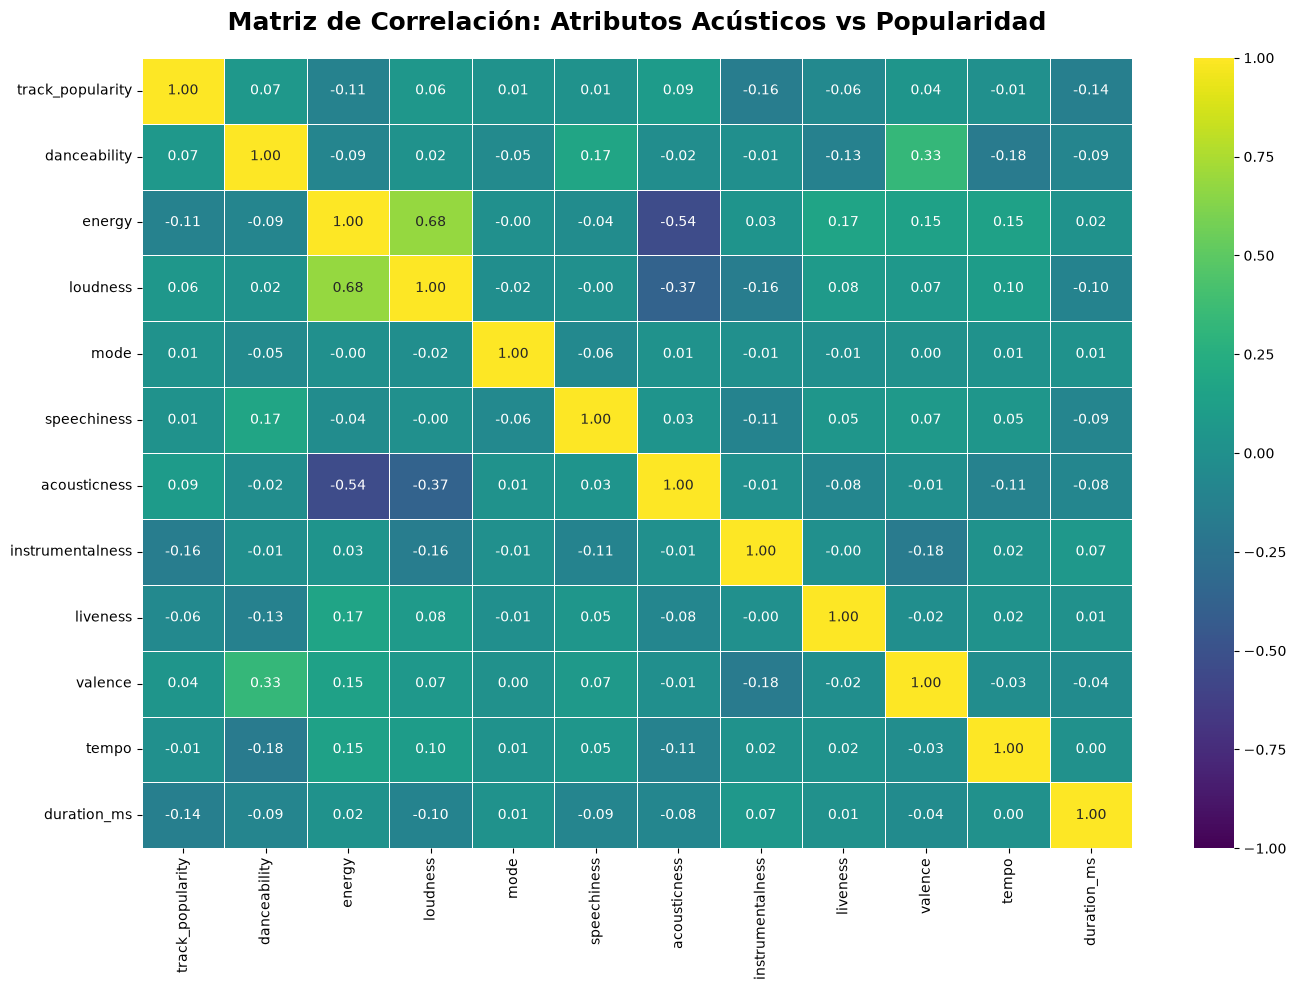

In [14]:
datos_numericos = dataNew.select_dtypes(include=['float64', 'int64', 'bool'])
matriz_correlacion = datos_numericos.corr()
plt.figure(figsize=(14, 10))
sns.heatmap(matriz_correlacion, annot=True, cmap='viridis', fmt=".2f", linewidths=.5, vmin=-1, vmax=1)

plt.title('Matriz de Correlación: Atributos Acústicos vs Popularidad', fontsize=18, fontweight='bold', pad=20)
plt.tight_layout()
plt.show()

Al desglosar numéricamente estas relaciones, la tabla confirma la ausencia de correlaciones lineales fuertes, ya que ningún valor supera el 0.16. Aunque se observan leves tendencias negativas en la instrumentalidad (-0.157) y la duración (-0.141), y ligeras influencias positivas en la acústica y la bailabilidad, el impacto aislado de cada métrica es mínimo.

In [15]:
correlacion_popularidad = matriz_correlacion['track_popularity'].sort_values(ascending=False)
print(correlacion_popularidad.drop('track_popularity'))

acousticness        0.086282
danceability        0.068846
loudness            0.058671
valence             0.041173
speechiness         0.011305
mode                0.010157
tempo              -0.005512
liveness           -0.055863
energy             -0.111947
duration_ms        -0.141681
instrumentalness   -0.157609
Name: track_popularity, dtype: float64


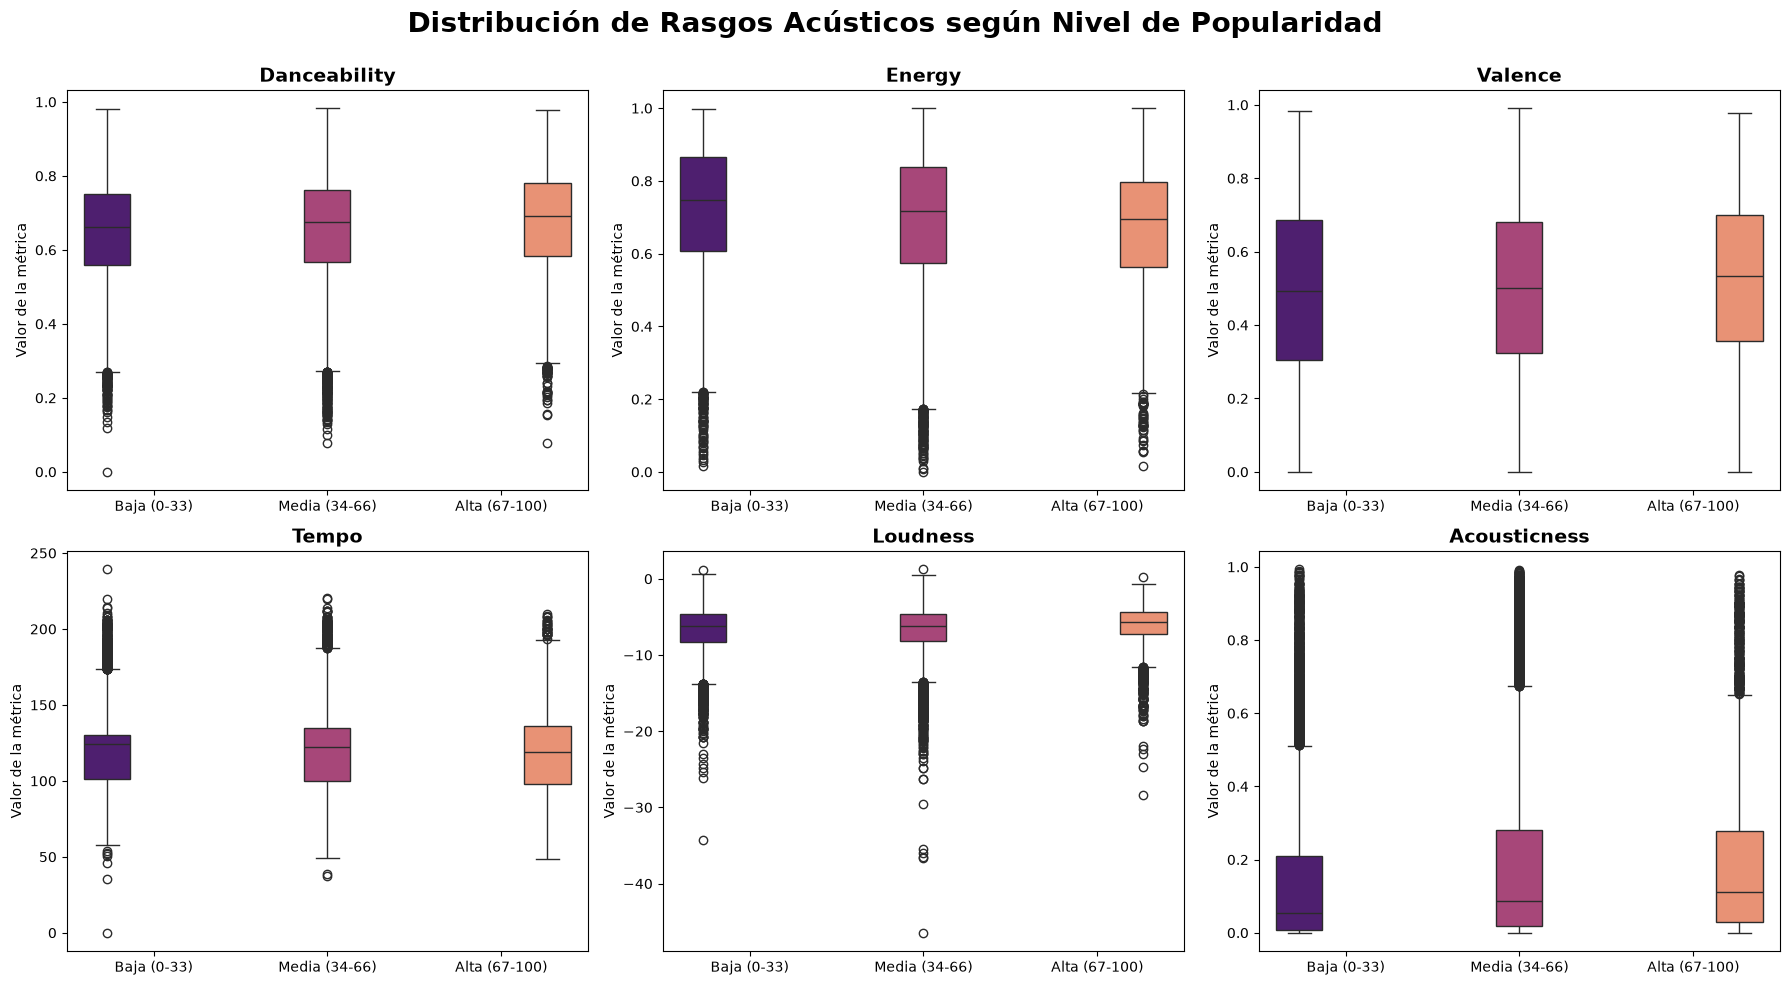

Medianas de cada rasgo por categoría:
                 danceability  energy  valence    tempo  loudness  \
categoria_exito                                                     
Baja (0-33)             0.661   0.747    0.493  123.984    -6.251   
Media (34-66)           0.675   0.718    0.502  121.990    -6.190   
Alta (67-100)           0.692   0.694    0.533  118.917    -5.720   

                 acousticness  
categoria_exito                
Baja (0-33)             0.055  
Media (34-66)           0.088  
Alta (67-100)           0.112  


In [19]:
cortes = [-1, 33, 66, 100]
nombres_categorias = ['Baja (0-33)', 'Media (34-66)', 'Alta (67-100)']

dataNew['categoria_exito'] = pd.cut(dataNew['track_popularity'], bins=cortes, labels=nombres_categorias)
features_a_graficar = ['danceability', 'energy', 'valence', 'tempo', 'loudness', 'acousticness']

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
fig.suptitle('Distribución de Rasgos Acústicos según Nivel de Popularidad', fontsize=20, fontweight='bold', y=0.98)
axes = axes.flatten()

for i, feature in enumerate(features_a_graficar):
    sns.boxplot(
        x='categoria_exito', 
        y=feature, 
        hue='categoria_exito',
        data=dataNew, 
        ax=axes[i], 
        palette='magma',
        legend=False
    )
    
    axes[i].set_title(f'{feature.capitalize()}', fontsize=14, fontweight='bold')
    axes[i].set_xlabel('')
    axes[i].set_ylabel('Valor de la métrica')

plt.tight_layout()
plt.subplots_adjust(top=0.90)
plt.show()

print("Medianas de cada rasgo por categoría:")
print(dataNew.groupby('categoria_exito')[features_a_graficar].median().round(3))

Para analizar la relación entre las características sonoras y el éxito se segmentó la popularidad en tres niveles y se construyen diagramas de caja, esto con el objetivo de evaluar si las canciones más populares poseen un perfil acústico distinto al de las menos escuchadas. 

Los gráficos y las medianas posteriormente mostradas revelan una gran similitud en todas las categorías, pues las medidas centrales se superponen casi por completo y factores como el tempo junto con la energía y la positividad mantienen rangos idénticos sin importar el éxito de la pista, solo se observa un aumento marginal en la bailabilidad y el volumen de las canciones más exitosas.  Esta visualización confirma que no existe una métrica individual que garantice la popularidad, como los grandes éxitos y los fracasos comparten una estructura sonora similar se demuestra que la popularidad musical es un fenómeno complejo.